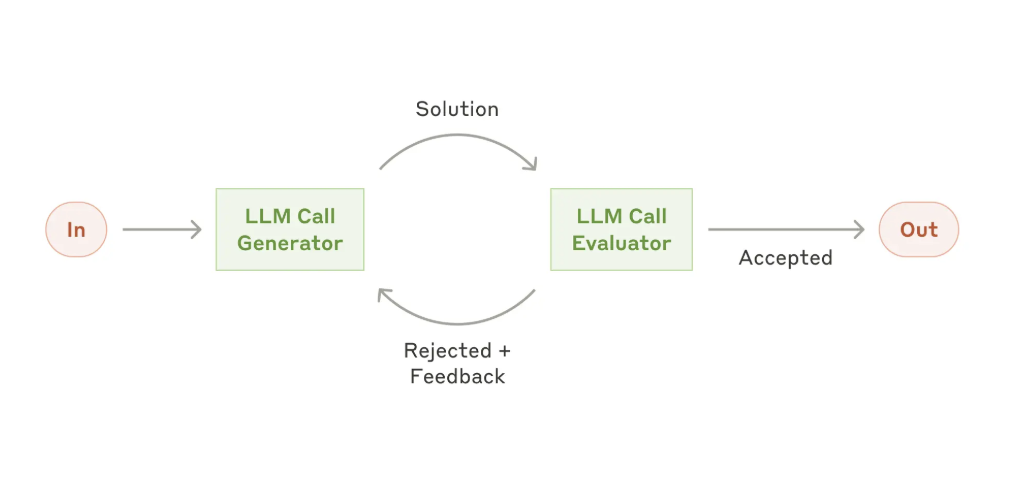

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

# 1.0. Import

In [4]:
from IPython.display import Image, display
from pydantic import BaseModel, Field

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

from typing_extensions import Literal

# 2.0. Hands-On

In [5]:
class State(TypedDict):
    topic: str
    joke: str
    feedback: str
    funny_or_not: str

In [7]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [6]:
class FeedBack(BaseModel):
    grade: Literal["funny", "not_funny"] = Field(..., title="Decide if the joke is funny or not.")
    feedback: str = Field(None, description="If the joke is not funny, provide feedback on how to improve it.")

In [10]:
evaluator = llm.with_structured_output(FeedBack)

In [13]:
evaluator.invoke("Bla Bla Bla")

FeedBack(grade='not_funny', feedback='The joke lacks content or a punchline. Try adding a setup and a clever twist to make it more engaging.')

In [11]:
def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")

    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

In [14]:
llm_call_evaluator(State(
    topic="jokes",
    joke="Bla Bla Bla",
    feedback="The joke lacks content or a punchline. Try adding a setup and a clever twist to make it more engaging.",
    funny_or_not=""
))

{'funny_or_not': 'not_funny',
 'feedback': 'The joke lacks substance and a punchline. To improve it, try adding a setup and a clever twist or a relatable situation that leads to a funny conclusion.'}

In [22]:
def llm_call_generator(state: State):
    """LLM generates a joked"""

    if state.get("feedback"):
        msg = llm.invoke(f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}")
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")

    return { "joke": msg.content }

In [23]:
llm_call_generator(State(
    topic="jokes",
    feedback="The joke lacks content or a punchline. Try adding a setup and a clever twist to make it more engaging.",
))

The joke lacks content or a punchline. Try adding a setup and a clever twist to make it more engaging.


{'joke': "Why did the joke go to therapy?\n\nBecause it couldn't find the punchline and felt like it was just telling itself!"}

In [24]:
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

In [25]:
optimizer_builder = StateGraph(State)

optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

optimizer_workflow = optimizer_builder.compile()

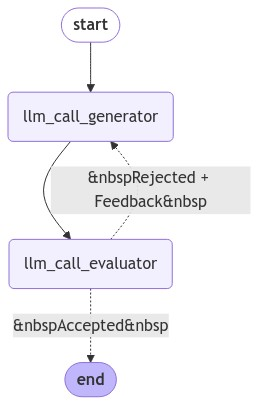

In [26]:
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# 3.0. Testing

In [27]:
state = optimizer_workflow.invoke({"topic": "Cats"})

In [28]:
print(state["joke"])

Why did the cat sit on the computer?

Because it wanted to keep an eye on the mouse!
